In [38]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_algebra import QR_dec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:

# plt.rcParams.update({
#     "text.usetex": True,           # Attiva l'uso di LaTeX per tutto il testo
#     "font.family": "serif",        # Usa un font Serif per il testo normale
#     "font.serif": ["Palatino"],    # Specifica Palatino (molto simile a quello in foto)
#     "axes.labelsize": 16,          # Dimensione font etichette assi
#     "font.size": 14,                # Dimensione font generale
#     "legend.fontsize": 14,         # Dimensione font legenda
#     "xtick.labelsize": 13,         # Dimensione numeri asse x
#     "ytick.labelsize": 13,         # Dimensione numeri asse y
#     "figure.figsize": (8, 6),      # Dimensione predefinita della figura
#     "figure.dpi": 100,             # Risoluzione
    
#     "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb}"
# })



## **Heat Equation**
Write a class that given the discrete set of coordinates $x_j$ calculates and stores the matrix $M_{jk}$. Add the methods dft and idft, both accepting an array of the same length as $x_j$ and returning either the direct or inverse DFT (internally the two methods apply either the matrix or its dagger).Starting from following parameters
- $L = 2\pi$ 
- $N = 128$
- $\alpha = 0.5$
- $u(x, 0) = \sin(x) + 0.5 \sin(3x)$
 
solve the 1d Heat equation by implementing these steps:apply the direct DFT to $u(x, 0)$ and calculate $\tilde{u}(k, 0)$ calculate $\tilde{u}(k, t)$ apply the inverse DFT to $\tilde{u}(k, t)$ to find $u(x, t)$

Repeat this operation for 20 values of $t \in [0, 2]$ and then plot them together.

(0.9583230745108544-7.069310281060608e-16j)
3.0
2.25


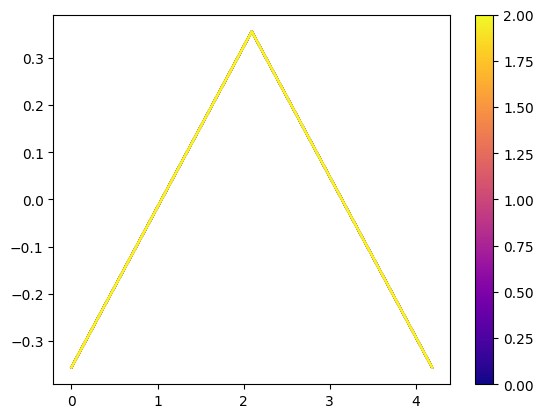

In [40]:
class DFT:
    def __init__(self, x_desc):
        N = len(x_desc)
        W = np.zeros((N, N), dtype=complex)
        L = (x_desc[-1] - x_desc[0])
        p_ls = []
        for k in range(N):
            pk = (2*np.pi / L ) * k
            p_ls.append(pk)
            for i in range(N):
                W[k][i] = np.exp(pk * x_desc[i]* 1j)   
        
        self.W = W
        self.L = L
        self.p = np.array(p_ls)
        self.dx = L / N
    
    def dft(self, y_desc):
        y_dft = self.dx * self.W @y_desc
        return y_dft

    def idft(self, y_desc):
        y_idft = self.dx * self.W.conj().T @ y_desc
        return y_idft
    

    # def dft(self, y_desc):
    #     y_dft = self.dx * np.dot(self.W, y_desc)
    #     return y_dft

    # def idft(self, y_desc):
    #     y_idft = self.dx * np.dot(self.W.conj().T, y_desc)
    #     return y_idft
    




def find_ut(ts):
    for ti in ts:
        u_ti = udf * np.exp(-alpha * (heat_dft.p)**2 * ti)
    return u_ti

Lmax = 2*np.pi
N_p = 3
alpha = 0.5
xcoo = np.linspace(0, Lmax, N_p, endpoint=False, dtype=float)
times = np.linspace(0, 2, 20, dtype=float)
u0 = np.sin(xcoo) + 0.5 * np.sin(3*xcoo)

heat_dft = DFT(xcoo)


# fourier transform of u(x,0) (p-space)
udf = heat_dft.dft(u0)
idf = heat_dft.idft(udf)
print(sum(udf - idf))

# print(udf[1])
# print(udf[-1])

# u(p,t), analitical solution in the p-space
ut = find_ut(times)

# inverse fourier transform of u(p,t) ---> u(x,t) (x-space)
uidf = heat_dft.idft(ut)


print(max(heat_dft.p))
print(np.pi/heat_dft.dx)




# --------------------------
#           PLOT
# --------------------------

cmap = plt.cm.plasma
colors = cmap(np.linspace(0, 1, len(times)))

plt.figure()
for i in range(len(times)):
    plt.plot(xcoo, uidf, color=colors[i])

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array(times)
plt.colorbar(sm, ax=plt.gca())
plt.show()